# Explore here

In [31]:
# Your code here
import pandas as pd

df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv')
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    str    
 1   sales   366 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.8 KB


In [33]:
df['date']=pd.to_datetime(df['date'])
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    366 non-null    datetime64[us]
 1   sales   366 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 5.8 KB


In [35]:
df.index = df.date
df.drop('date', axis=1, inplace=True)
df.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


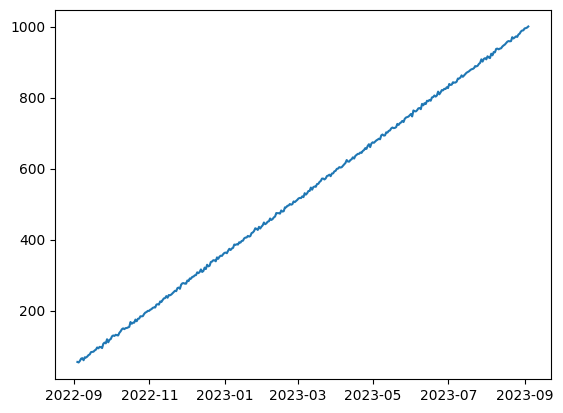

In [36]:
import matplotlib.pyplot as plt 
plt.plot(df)

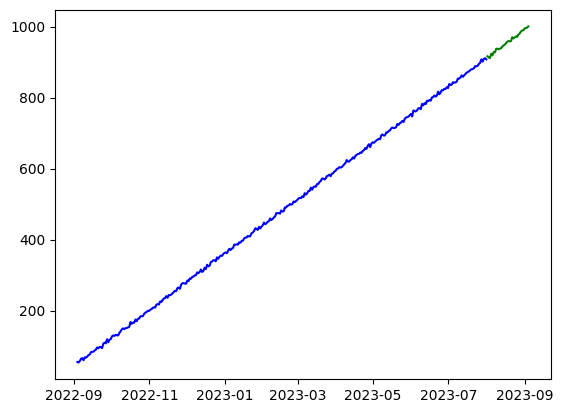

In [37]:
df_train = df[df.index <= '2023-08-01']
df_test = df[df.index > '2023-08-01']

plt.plot(df_train, color='blue')
plt.plot(df_test, color='green')

In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose

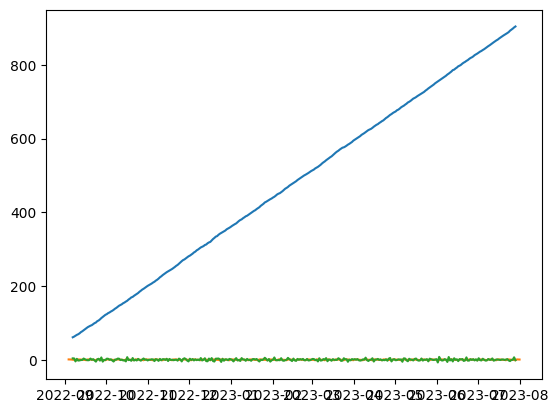

In [39]:
seasonal = seasonal_decompose(df_train , period = 7)
trend = seasonal.trend
estacionalidad = seasonal.seasonal
error = seasonal.resid

plt.plot(trend)
plt.plot(estacionalidad)
plt.plot(error)

In [40]:

from pmdarima import auto_arima

model = auto_arima(df_train)
model = auto_arima(df_train, m=7, seasonal=False, trace=True)


/home/vscode/.local/lib/python3.11/site-packages/pmdarima/arima/_validation.py:62: UserWarning: m (7) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1673.403, Time=0.49 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1904.573, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1792.947, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1670.865, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2005.236, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1670.214, Time=0.13 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1672.117, Time=0.28 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1674.856, Time=0.10 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1670.139, Time=0.30 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=1672.113, Time=0.15 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.32 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1966.589, Time=0.03 sec

Best model:  ARIMA(0,1,2)(0,0,0)[0] intercept
Total fit time: 1.952 seconds


In [44]:
sales_predict = model.predict(34)
sales_predict

2023-08-01 17:10:08.079328    914.086751
2023-08-02 17:10:08.079328    916.379149
2023-08-03 17:10:08.079328    918.975976
2023-08-04 17:10:08.079328    921.572804
2023-08-05 17:10:08.079328    924.169632
2023-08-06 17:10:08.079328    926.766459
2023-08-07 17:10:08.079328    929.363287
2023-08-08 17:10:08.079328    931.960115
2023-08-09 17:10:08.079328    934.556943
2023-08-10 17:10:08.079328    937.153770
2023-08-11 17:10:08.079328    939.750598
2023-08-12 17:10:08.079328    942.347426
2023-08-13 17:10:08.079328    944.944253
2023-08-14 17:10:08.079328    947.541081
2023-08-15 17:10:08.079328    950.137909
2023-08-16 17:10:08.079328    952.734736
2023-08-17 17:10:08.079328    955.331564
2023-08-18 17:10:08.079328    957.928392
2023-08-19 17:10:08.079328    960.525220
2023-08-20 17:10:08.079328    963.122047
2023-08-21 17:10:08.079328    965.718875
2023-08-22 17:10:08.079328    968.315703
2023-08-23 17:10:08.079328    970.912530
2023-08-24 17:10:08.079328    973.509358
2023-08-25 17:10

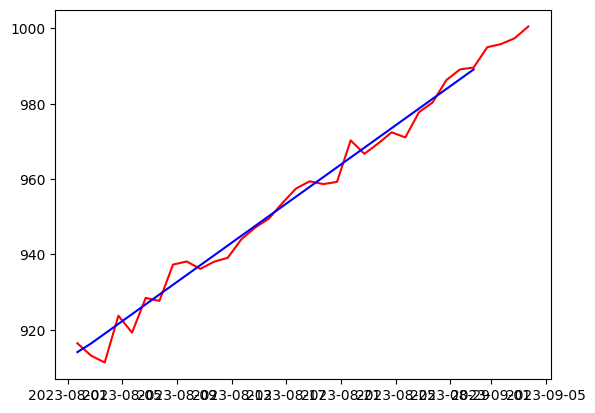

In [42]:
plt.plot(df_test, color='red')
plt.plot(sales_predict, color='blue')
plt.show()

In [45]:
from sklearn.metrics import root_mean_squared_error, r2_score

error_2 = root_mean_squared_error(df_test, sales_predict)
r2 = r2_score(df_test, sales_predict)

print(f'El error cuadratico medio en raiz es de {error_2} y el R2 es de {r2}')

El error cuadratico medio en raiz es de 2.8347645458529587 y el R2 es de 0.9882747345147518


- ¿Cuál es el tensor de la serie temporal?
* Diario 
- ¿Cuál es la tendencia?
* Ascendente
- ¿Es estacionaria?
* No es estacionaria debido que no se detiene en el tiempo 
- ¿Existe variabilidad o presencia de ruido?
* No existe debido a que es muy poco

In [50]:
import os
from pickle import dump

# 1. Definir la ruta de la carpeta y el nombre del archivo
folder_path = '../workspaces/tsa_alternativo/models/'
file_name = 'arima_model.pkl'

# 2. Crear la carpeta si no existe
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# 3. Guardar el modelo
dump(model, open(os.path.join(folder_path, file_name), 'wb'))

print(f"Modelo guardado exitosamente en: {folder_path}{file_name}")

Modelo guardado exitosamente en: ../workspaces/tsa_alternativo/models/arima_model.pkl
